# MunchLink Food Hub - Data Analysis

## Background

MunchLink is a food delivery platform operating across multiple city zones. With thousands of orders flowing through the platform, the business needs to understand what's working and what isn't, from delivery times and customer ratings to restaurant performance and revenue.

This analysis looks at 1,898 orders to answer some key operational and business questions:

- How many customers aren't leaving ratings, and why does that matter?
- Which restaurants are driving the most volume?
- Where are deliveries taking too long?
- Which zones have the most service problems?
- How is commission revenue distributed across cuisines and order types?

The goal is to get a clear picture of platform performance and spot areas that need attention.

## Objective

Work through the data to understand MunchLink's order patterns, delivery performance, and customer behaviour and pull out findings that are actually useful for decision making.

## Data Dictionary

| Column | Description |
|--------|-------------|
| order_id | Unique order identifier |
| customer_id | Customer identifier |
| restaurant_name | Restaurant name |
| cuisine_type | Cuisine category |
| cost_of_the_order | Order cost (USD) |
| day_of_the_week | Weekday or Weekend |
| rating | Customer rating (1-5 or Not given) |
| food_preparation_time | Prep time (minutes) |
| delivery_time | Delivery time (minutes) |
| total_fulfillment_time | Total prep + delivery time |
| prep_to_delivery_ratio | Prep speed vs delivery speed ratio |
| cost_bucket | Order cost category (Budget/Standard/Premium/Luxury) |
| speed_bucket | Fulfillment speed category |
| weather_condition | Weather condition |
| delivery_zone | Delivery zone (Downtown/Midtown/Uptown/Suburban) |
| is_group_order | Group order flag |
| service_issue_flag | Service issue flag |
| platform_commission | Platform commission (USD) |

In [1]:
#Import libraries for data manipulation
import numpy as np
import pandas as pd

#Import libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt


## Data Exploration & Structure


In [2]:
# Load the CSV file into a dataframe 
df = pd.read_csv(r'munchlink_orders_enhanced.csv')

# Show the first 5 rows so we can preview what the data looks like
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_fulfillment_time,prep_to_delivery_ratio,cost_bucket,speed_bucket,weather_condition,delivery_zone,is_group_order,service_issue_flag,platform_commission
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,45,1.25,Luxury,Normal,Rainy,Uptown,Yes,No,7.69
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,48,1.09,Standard,Normal,Cloudy,Uptown,No,No,1.81
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,51,0.82,Standard,Normal,Cloudy,Midtown,No,No,1.83
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,40,1.67,Premium,Fast,Rainy,Downtown,Yes,No,7.30
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,49,1.04,Standard,Normal,Rainy,Downtown,No,No,1.74


**What this shows:** The table above is a preview of the data. Each row is one order. You can see all 18 columns, things like the restaurant name, cost, delivery time, rating, and more. This is just a snapshot; the full dataset has 1,898 rows.

In [3]:
# Show the last 5 rows 
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_fulfillment_time,prep_to_delivery_ratio,cost_bucket,speed_bucket,weather_condition,delivery_zone,is_group_order,service_issue_flag,platform_commission
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17,48,1.82,Premium,Normal,Sunny,Suburban,Yes,No,5.58
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19,50,1.63,Standard,Normal,Sunny,Midtown,No,No,1.83
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24,55,1.29,Premium,Normal,Sunny,Downtown,Yes,No,6.30
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31,54,0.74,Standard,Normal,Cloudy,Midtown,No,No,1.83
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24,52,1.17,Standard,Normal,Sunny,Suburban,No,No,2.92


**What this shows:** The last rows look consistent with the rest of the data with no obvious errors or cut-offs at the end of the file.

In [4]:
# Check what type of data is stored in each column
# 'object' = text,  'int64' = whole numbers,  'float64' = decimal numbers
print("Column data types:")
df.dtypes

Column data types:


order_id                    int64
customer_id                 int64
restaurant_name            object
cuisine_type               object
cost_of_the_order         float64
day_of_the_week            object
rating                     object
food_preparation_time       int64
delivery_time               int64
total_fulfillment_time      int64
prep_to_delivery_ratio    float64
cost_bucket                object
speed_bucket               object
weather_condition          object
delivery_zone              object
is_group_order             object
service_issue_flag         object
platform_commission       float64
dtype: object

**What this shows:** Columns labelled `object` store text (e.g. restaurant names, cuisine types). Columns labelled `int64` or `float64` store numbers. Only number columns can be used in calculations like averages.

In [5]:
# Get a quick overview: total rows, columns, data types, and whether any values are missing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                1898 non-null   int64  
 1   customer_id             1898 non-null   int64  
 2   restaurant_name         1898 non-null   object 
 3   cuisine_type            1898 non-null   object 
 4   cost_of_the_order       1898 non-null   float64
 5   day_of_the_week         1898 non-null   object 
 6   rating                  1898 non-null   object 
 7   food_preparation_time   1898 non-null   int64  
 8   delivery_time           1898 non-null   int64  
 9   total_fulfillment_time  1898 non-null   int64  
 10  prep_to_delivery_ratio  1898 non-null   float64
 11  cost_bucket             1898 non-null   object 
 12  speed_bucket            1898 non-null   object 
 13  weather_condition       1898 non-null   object 
 14  delivery_zone           1898 non-null   

**What this shows:** We have 1,898 rows and 18 columns. All columns show 1,898 non-null entries, meaning no blank values in the raw data. However, the `rating` column uses the text "Not given" instead of a real blank, so we need to handle that manually in the next step.

### Are there missing values in the data?

In [6]:
# Count how many blank (missing) values exist in each column
# A value of 0 means that column has no missing data
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


order_id                  0
customer_id               0
restaurant_name           0
cuisine_type              0
cost_of_the_order         0
day_of_the_week           0
rating                    0
food_preparation_time     0
delivery_time             0
total_fulfillment_time    0
prep_to_delivery_ratio    0
cost_bucket               0
speed_bucket              0
weather_condition         0
delivery_zone             0
is_group_order            0
service_issue_flag        0
platform_commission       0
dtype: int64

**What this shows:** All columns return 0 missing values in the raw file. But this doesn't tell the full story. The `rating` column stores "Not given" as text, which Python doesn't recognise as a missing value. We fix this in the next cell.

In [7]:
# The rating column stores 'Not given' as text. Python doesn't know that means "missing"
# We replace it with NaN (Not a Number), which Python treats as a proper blank
df['rating'] = df['rating'].replace('Not given', np.nan)

# Create a new column 'rating_num' that stores ratings as actual numbers (3.0, 4.0, 5.0)
# calculate averages and draw charts 
df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce')

**What this does:** The `rating` column is now cleaned. "Not given" entries are treated as blank (missing). A new column called `rating_num` has been added with ratings stored as actual numbers (3.0, 4.0, 5.0), so we can compute averages and draw charts later.

In [8]:
# Summary statistics for every number column: count, average (mean), min, max, and middle values
# This gives a quick sense of the ranges and typical values in the data
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time,total_fulfillment_time,prep_to_delivery_ratio,platform_commission,rating_num
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000,1898.000000,1162.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749,51.533720,1.187608,3.248946,4.344234
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637,6.833603,0.340414,2.295686,0.741478
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000,35.000000,0.610000,0.000000,3.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000,47.000000,0.940000,1.810000,4.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000,52.000000,1.130000,2.120000,5.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000,56.000000,1.360000,5.577500,5.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000,68.000000,2.330000,8.850000,5.000000


**Quick takeaways from the summary:** The average order costs about **$16**. Food prep takes **20 to 35 minutes** for most orders. Average delivery is about **24 minutes**. Total fulfillment time (prep + delivery) averages around **51 minutes**. These numbers give us a baseline before we dig deeper.

### Rating Distribution

In [9]:
# Count how many orders received each rating value, treating blank ratings as 'Not given'
not_rating = df['rating'].fillna('Not given').value_counts()
print(not_rating)

# Print just the count of orders with no rating
print(f'\nOrders with no rating: {not_rating.get("Not given", 0)}')

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

Orders with no rating: 736


**What this shows:** **736 out of 1,898 orders (38.8%) have no rating at all.** Nearly 4 in every 10 customers didn't leave a review. This matters because ratings are how the platform judges restaurant quality. With so many missing, the feedback data is incomplete.

## Exploratory Data Analysis (EDA)

### Univariate Checks

#### a. Order ID (Uniqueness Check)

In [10]:
# Count the number of unique order IDs, should equal 1,898 (one ID per order, no duplicates)
df['order_id'].nunique()

1898

**What this shows:** The result should be 1,898, meaning every single row has its own unique order ID. No duplicate orders in the dataset. This confirms the data is clean at the order level.

#### b. Customer ID (Uniqueness Check)

In [11]:
# Count unique customers — will be less than 1,898 because some customers placed multiple orders
df['customer_id'].nunique()

1200

**What this shows:** The number of unique customers is less than 1,898, which means some customers have placed more than one order. That's expected for a food delivery platform regulars order repeatedly.

#### c. Restaurant Name (Uniqueness Check)

In [12]:
# Count how many different restaurants appear in the dataset
df['restaurant_name'].nunique()

178

**What this shows:** This is the total number of different restaurants on the platform. With 1,898 orders spread across this many restaurants, a small group of busy ones handles a much larger share of orders than the rest (which we will see in Q2).


#### d. Cuisine Type Distribution

In [13]:
# Check unique cuisine type
df['cuisine_type'].nunique() ## Complete the code to find out  number of  unique cuisine type

14

<Axes: xlabel='cuisine_type', ylabel='count'>

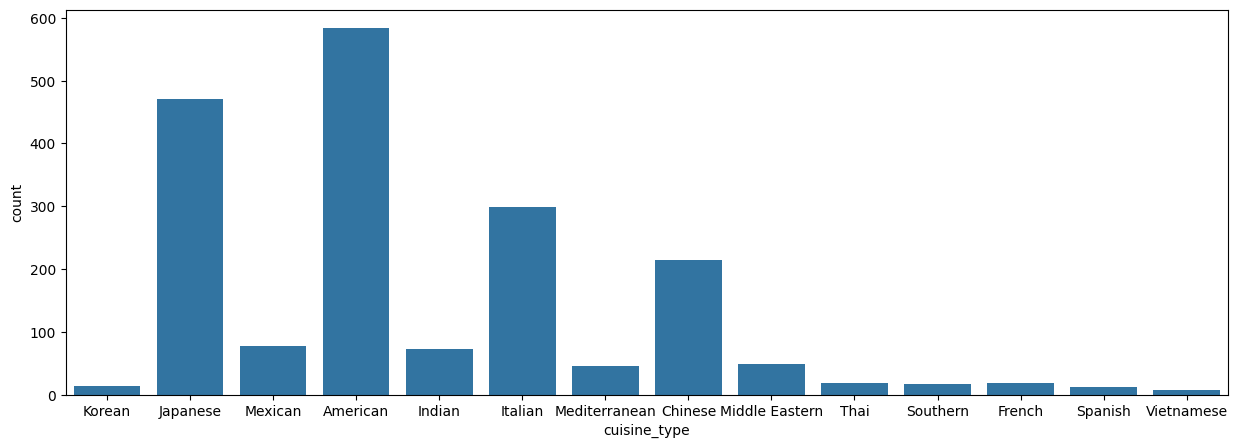

In [14]:
#Create a countplot for cuisine type.
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'cuisine_type') 

**What this shows:** American, Japanese, and Italian are among the most frequently ordered cuisines in this dataset.

#### e. Key Operational Distributions

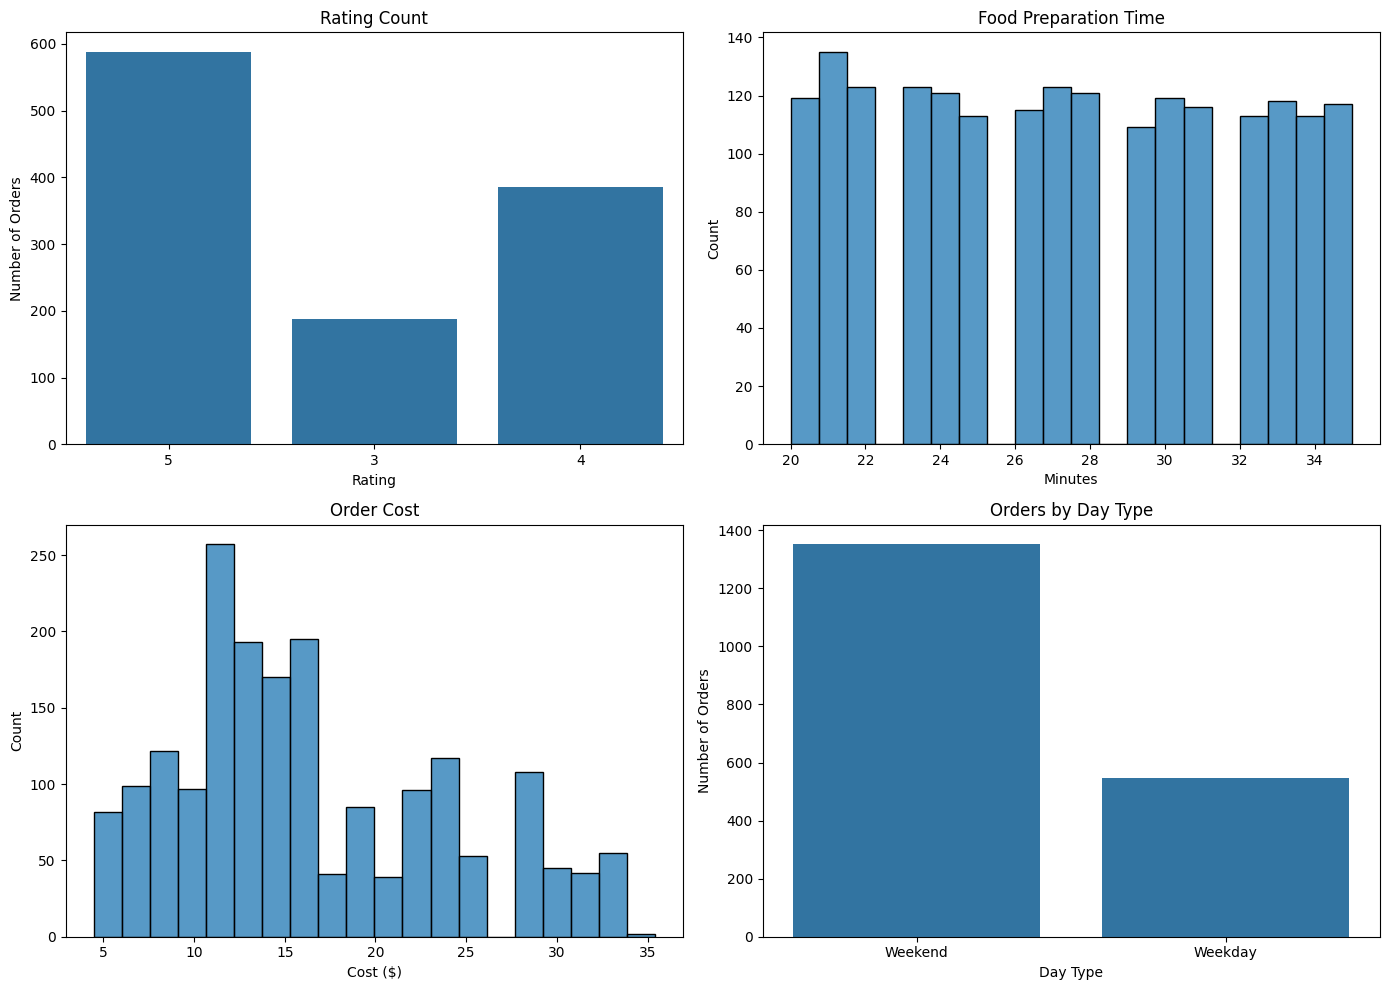

In [15]:
# Simple overview charts for the main variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rating count
sns.countplot(data=df, x='rating', ax=axes[0, 0])
axes[0, 0].set_title('Rating Count')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Number of Orders')

# Food preparation time
sns.histplot(data=df, x='food_preparation_time', bins=20, ax=axes[0, 1])
axes[0, 1].set_title('Food Preparation Time')
axes[0, 1].set_xlabel('Minutes')
axes[0, 1].set_ylabel('Count')

# Order cost
sns.histplot(data=df, x='cost_of_the_order', bins=20, ax=axes[1, 0])
axes[1, 0].set_title('Order Cost')
axes[1, 0].set_xlabel('Cost ($)')
axes[1, 0].set_ylabel('Count')

# Day type
sns.countplot(data=df, x='day_of_the_week', ax=axes[1, 1])
axes[1, 1].set_title('Orders by Day Type')
axes[1, 1].set_xlabel('Day Type')
axes[1, 1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Reading the charts:**
- **Rating count:** Most visible ratings are 4 or 5. Lower ratings are much less common.
- **Food preparation time:** Most orders are prepared within a fairly narrow time range.
- **Order cost:** A large share of orders sits in the middle price range.
- **Day type:** Weekend orders are clearly higher than weekday orders.

### Multivariate Analysis

This section checks how important variables relate to each other.

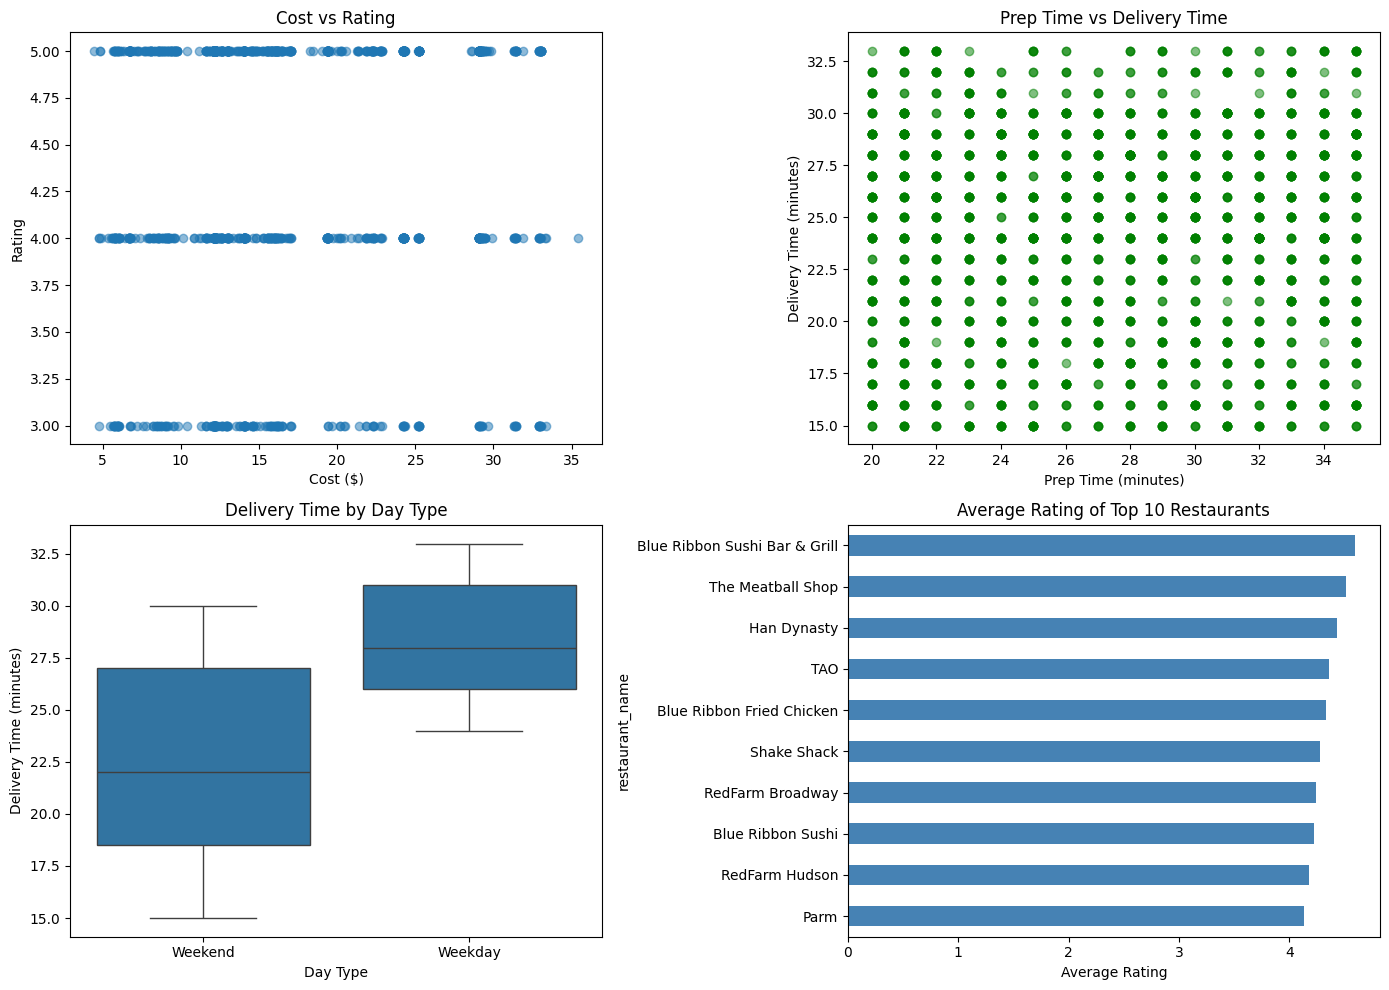

In [16]:
# Simple relationship charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cost vs rating
rated_orders = df.dropna(subset=['rating_num'])
axes[0, 0].scatter(rated_orders['cost_of_the_order'], rated_orders['rating_num'], alpha=0.5)
axes[0, 0].set_title('Cost vs Rating')
axes[0, 0].set_xlabel('Cost ($)')
axes[0, 0].set_ylabel('Rating')

# Prep time vs delivery time
axes[0, 1].scatter(df['food_preparation_time'], df['delivery_time'], alpha=0.5, color='green')
axes[0, 1].set_title('Prep Time vs Delivery Time')
axes[0, 1].set_xlabel('Prep Time (minutes)')
axes[0, 1].set_ylabel('Delivery Time (minutes)')

# Delivery time by day type
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time', ax=axes[1, 0])
axes[1, 0].set_title('Delivery Time by Day Type')
axes[1, 0].set_xlabel('Day Type')
axes[1, 0].set_ylabel('Delivery Time (minutes)')

# Average rating for top restaurants
top_restaurants = df['restaurant_name'].value_counts().head(10).index
top_restaurant_ratings = df[df['restaurant_name'].isin(top_restaurants)]
top_restaurant_ratings = top_restaurant_ratings.dropna(subset=['rating_num'])
top_restaurant_ratings = top_restaurant_ratings.groupby('restaurant_name')['rating_num'].mean().sort_values()
top_restaurant_ratings.plot(kind='barh', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Average Rating of Top 10 Restaurants')
axes[1, 1].set_xlabel('Average Rating')

plt.tight_layout()
plt.show()

**Reading the charts:**
- **Cost vs rating:** There is no strong pattern between spending more and giving a higher rating.
- **Prep time vs delivery time:** These two times do not move together in a clear way.
- **Delivery time by day type:** Weekday deliveries tend to be slower than weekend deliveries.
- **Top restaurant ratings:** The busiest restaurants mostly keep ratings in a similar high range.

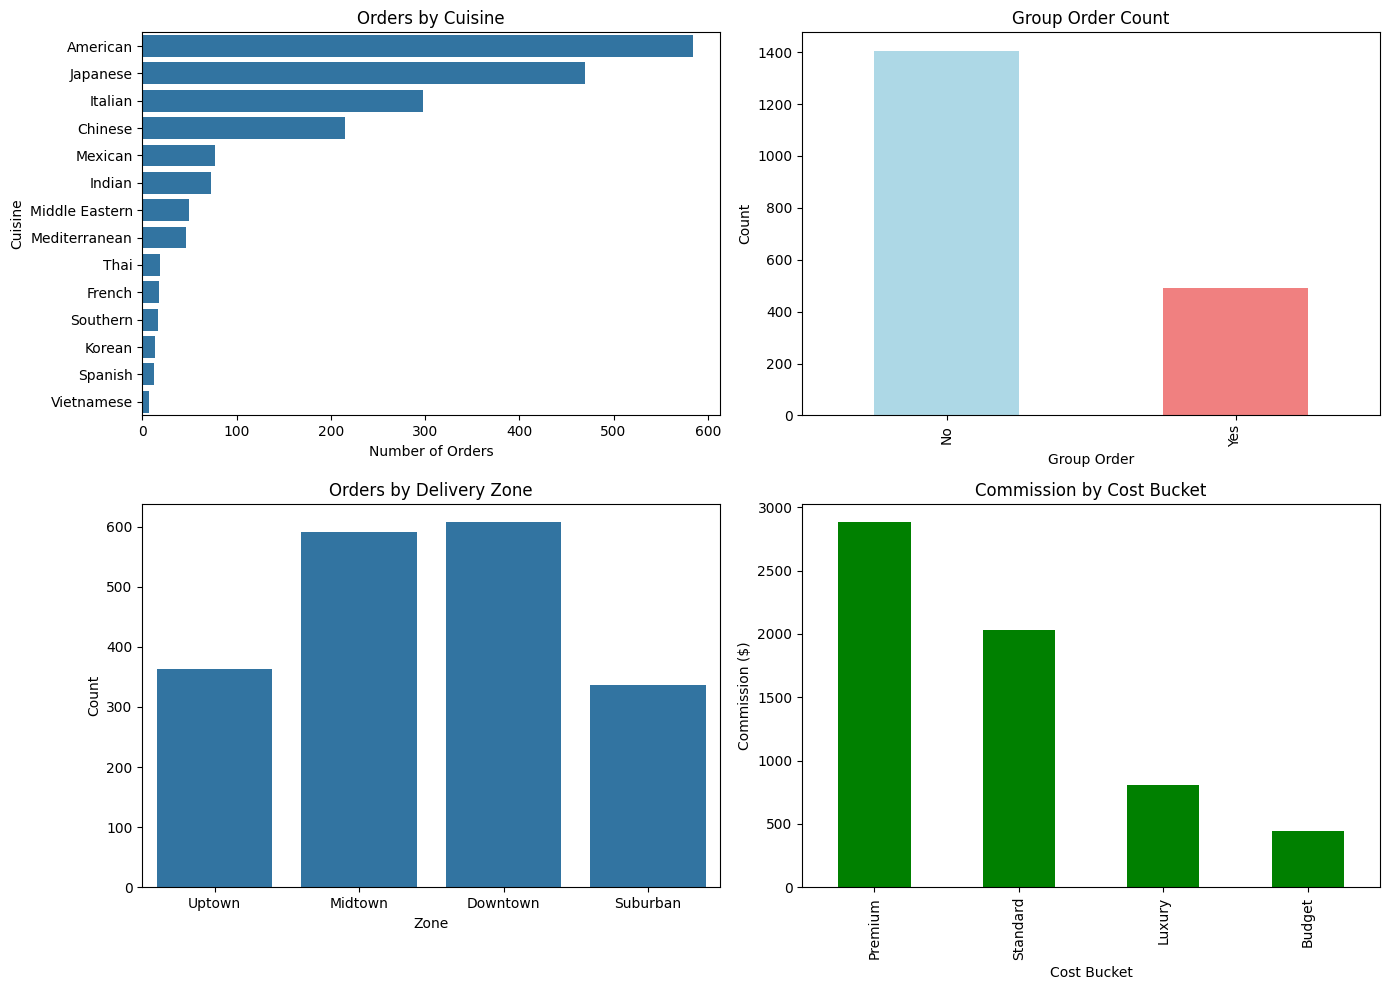

In [17]:
# More simple charts for categories and revenue
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Orders by cuisine
sns.countplot(data=df, y='cuisine_type', order=df['cuisine_type'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Orders by Cuisine')
axes[0, 0].set_xlabel('Number of Orders')
axes[0, 0].set_ylabel('Cuisine')

# Group orders
group_counts = df['is_group_order'].value_counts()
group_counts.plot(kind='bar', ax=axes[0, 1], color=['lightblue', 'lightcoral'])
axes[0, 1].set_title('Group Order Count')
axes[0, 1].set_xlabel('Group Order')
axes[0, 1].set_ylabel('Count')

# Orders by delivery zone
sns.countplot(data=df, x='delivery_zone', ax=axes[1, 0])
axes[1, 0].set_title('Orders by Delivery Zone')
axes[1, 0].set_xlabel('Zone')
axes[1, 0].set_ylabel('Count')

# Commission by cost bucket
commission_by_bucket = df.groupby('cost_bucket')['platform_commission'].sum().sort_values(ascending=False)
commission_by_bucket.plot(kind='bar', ax=axes[1, 1], color='green')
axes[1, 1].set_title('Commission by Cost Bucket')
axes[1, 1].set_xlabel('Cost Bucket')
axes[1, 1].set_ylabel('Commission ($)')

plt.tight_layout()
plt.show()

**Reading the charts:**
- **Orders by cuisine:** American cuisine appears most often, followed by a few other strong categories.
- **Group orders:** Most orders are regular individual orders, while group orders are a smaller share.
- **Orders by delivery zone:** Some zones handle much more order volume than others.
- **Commission by cost bucket:** Higher value buckets bring in more commission overall.

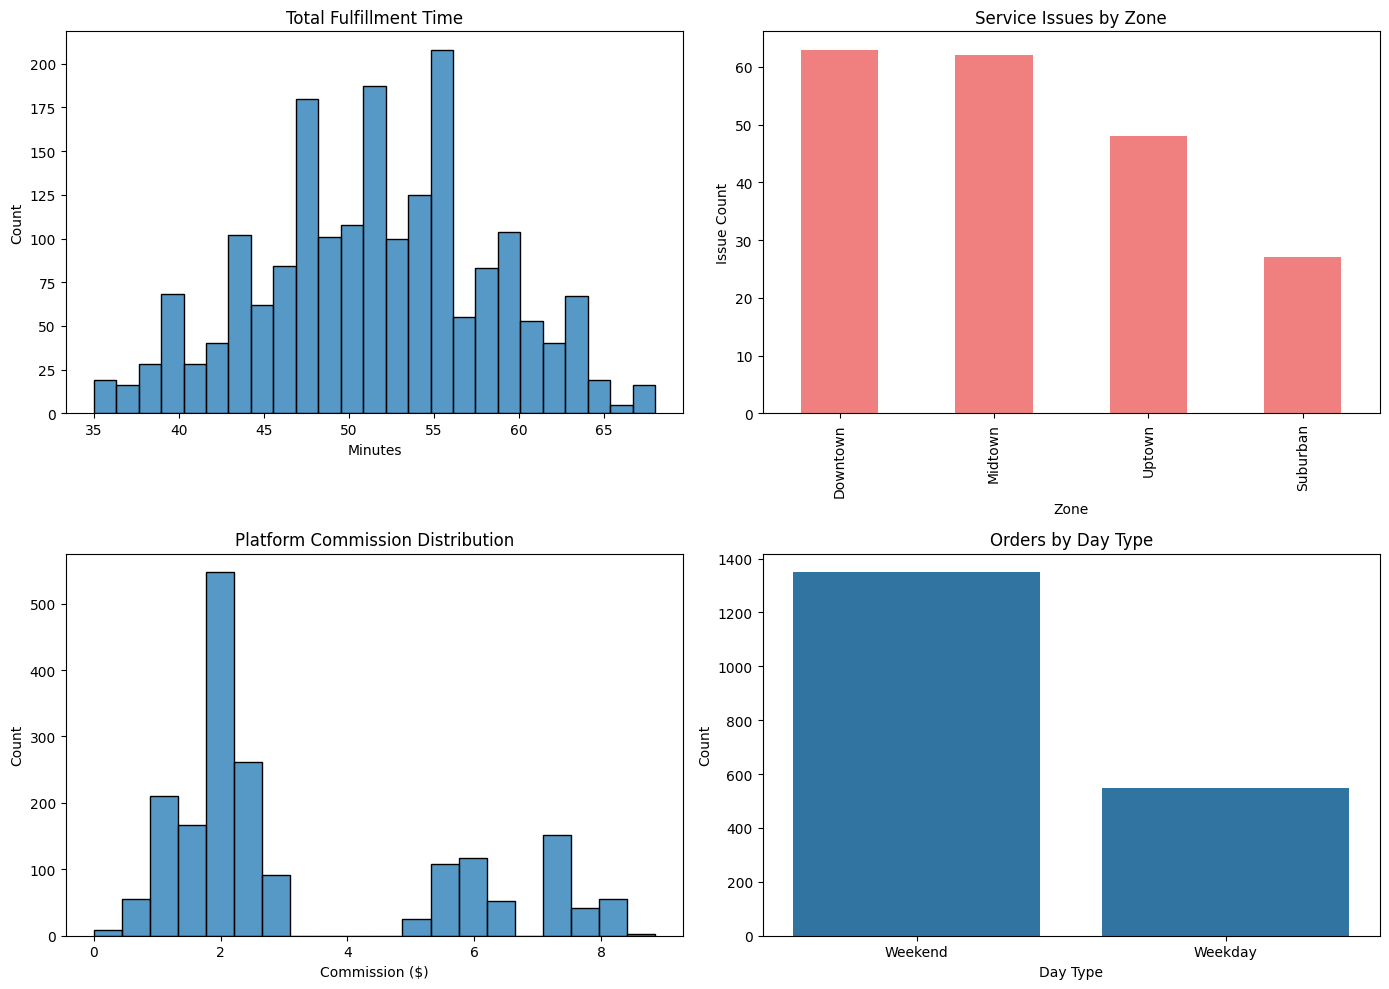

In [18]:
# Simple charts for fulfillment and service issues
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total fulfillment time
sns.histplot(data=df, x='total_fulfillment_time', bins=25, ax=axes[0, 0])
axes[0, 0].set_title('Total Fulfillment Time')
axes[0, 0].set_xlabel('Minutes')
axes[0, 0].set_ylabel('Count')

# Service issue count by zone
issue_mask = df['service_issue_flag'].isin(['Yes', 1, True])
issue_counts = df[issue_mask]['delivery_zone'].value_counts()
issue_counts.plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Service Issues by Zone')
axes[0, 1].set_xlabel('Zone')
axes[0, 1].set_ylabel('Issue Count')

# Commission distribution
sns.histplot(data=df, x='platform_commission', bins=20, ax=axes[1, 0])
axes[1, 0].set_title('Platform Commission Distribution')
axes[1, 0].set_xlabel('Commission ($)')
axes[1, 0].set_ylabel('Count')

# Orders by day type
sns.countplot(data=df, x='day_of_the_week', ax=axes[1, 1])
axes[1, 1].set_title('Orders by Day Type')
axes[1, 1].set_xlabel('Day Type')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Reading the charts:**
- **Total fulfillment time:** Most orders are completed in a similar time band, with fewer very slow orders.
- **Service issues by zone:** Some zones have more service problems than others and may need attention.
- **Commission distribution:** Many orders generate smaller commission amounts, while fewer orders generate larger amounts.
- **Orders by day type:** Weekend order count is higher than weekday order count.

---

The EDA charts above give us a broad picture of the data. Now we move into specific business questions to dig deeper into each area.

### What are the core order patterns across cost, delivery time, cuisine, and day type?

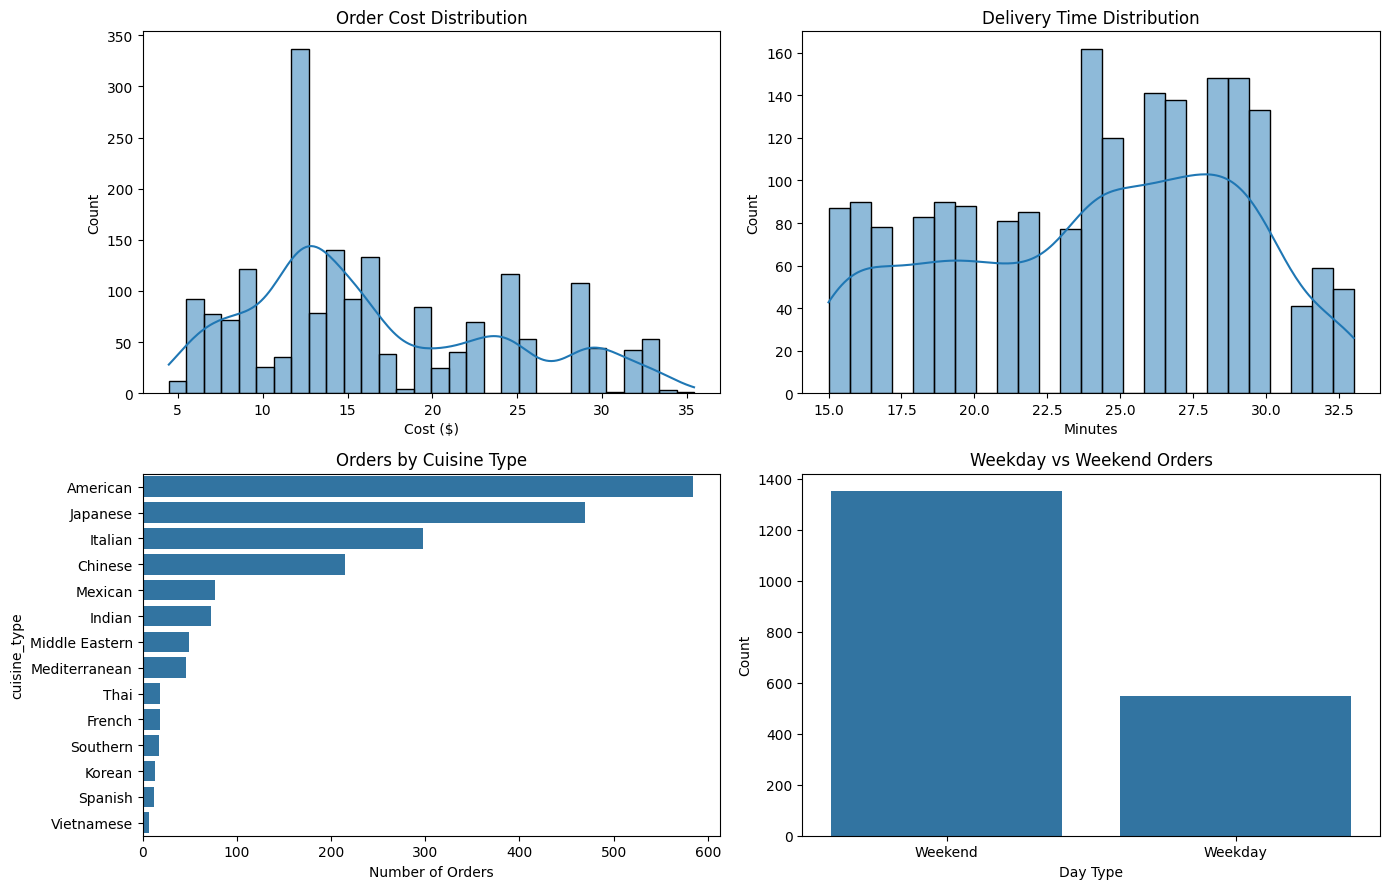

In [19]:
# 4 charts showing the spread of order cost, delivery time, cuisine popularity, and day type
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# How much do orders usually cost? (top-left)  kde=True adds a smooth curve on top of the bars
sns.histplot(df['cost_of_the_order'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Order Cost Distribution')
axes[0, 0].set_xlabel('Cost ($)')

# How long does delivery take most of the time? (top-right)
sns.histplot(df['delivery_time'], bins=25, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Delivery Time Distribution')
axes[0, 1].set_xlabel('Minutes')

# Which cuisines are ordered most? Sorted from most to least (bottom-left)
sns.countplot(data=df, y='cuisine_type', order=df['cuisine_type'].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title('Orders by Cuisine Type')
axes[1, 0].set_xlabel('Number of Orders')

# Are more orders on weekdays or weekends? (bottom-right)
sns.countplot(data=df, x='day_of_the_week', ax=axes[1, 1])
axes[1, 1].set_title('Weekday vs Weekend Orders')
axes[1, 1].set_xlabel('Day Type')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Result:** Order costs cluster around $12 to 15. Delivery times peak between 20 to 30 minutes. American food is by far the most popular cuisine. Weekends have roughly **2.5× more orders** than weekdays (around 1,340 vs 558).

### Which restaurants receive the highest number of orders?

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


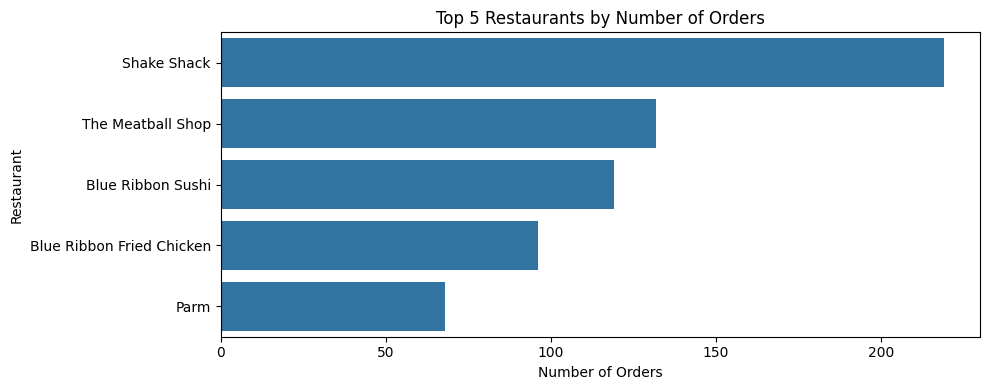

In [20]:
# Count total orders per restaurant and keep only the top 5
top5_restaurants = df['restaurant_name'].value_counts().head(5)
print(top5_restaurants)

# Visualise the top 5 as a horizontal bar chart
plt.figure(figsize=(10, 4))
sns.barplot(x=top5_restaurants.values, y=top5_restaurants.index)
plt.title('Top 5 Restaurants by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Restaurant')
plt.tight_layout()
plt.show()

**Result:** The top 5 restaurants are **Shake Shack (219 orders)**, The Meatball Shop (132), Blue Ribbon Sushi (119), Blue Ribbon Fried Chicken (96), and Parm (68). Just these 5 restaurants account for about a third of all orders, making them MunchLink's most valuable partners.

### Which cuisine types are most popular during weekends?

In [21]:
# Filter the dataframe to only weekend rows, then count orders by cuisine type
weekend_top = df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts()
print(weekend_top.head(5))

cuisine_type
American    415
Japanese    335
Italian     207
Chinese     163
Mexican      53
Name: count, dtype: int64


**Result:** On weekends, **American food leads by a large margin**, followed by Japanese, then Italian. If MunchLink runs weekend promotions, American and Japanese cuisines are the safest targets.

### What percentage of orders are high-value orders (cost > $20)?

In [22]:
# Keep only orders that cost more than $20
high_value_orders = df[df['cost_of_the_order'] > 20]

# Count totals
total_orders = len(df)
high_value_count = len(high_value_orders)

# Convert to percentage
pct_gt_20 = (high_value_count / total_orders) * 100

print(f'High-value orders: {high_value_count} out of {total_orders}')
print(f'Percentage of orders above $20: {pct_gt_20:.2f}%')

High-value orders: 555 out of 1898
Percentage of orders above $20: 29.24%


**Result:** About **29.24% of orders** exceed $20. MunchLink charges a higher commission on these orders (25% vs 15% for cheaper ones), so each one brings in more revenue than a standard order.

### What is the average delivery time across all orders?

In [23]:
# Calculate the average delivery time across all 1,898 orders
# Note: this is only the delivery leg — food prep time is separate
mean_delivery_time = df['delivery_time'].mean()
print(f'Mean delivery time: {mean_delivery_time:.2f} minutes')

Mean delivery time: 24.16 minutes


**Result:** The average delivery time is **24.16 minutes**. This is only the delivery leg (once the driver picks up the food). Food preparation time adds another ~27 minutes on top, giving a total of ~51 minutes from order to door.

### Who are the most frequent customers on the platform?

In [24]:
# Count how many orders each customer placed, then show the top 3 most frequent customers
top_customers = df['customer_id'].value_counts().head(3)
print(top_customers)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


**Result:** The 3 most frequent customers placed **13, 10, and 9 orders** respectively. These highly loyal customers are valuable  losing them would have more impact than losing occasional one-time users.

### What relationships exist among key numeric variables and delivery timing?

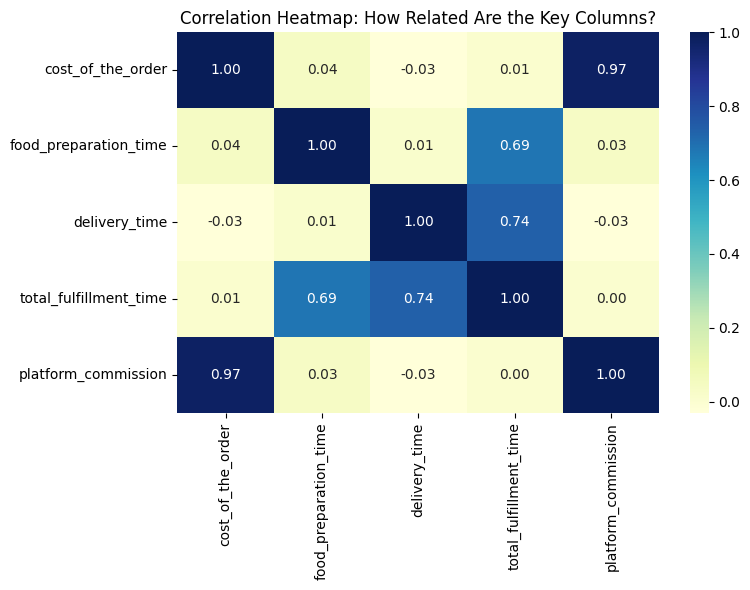

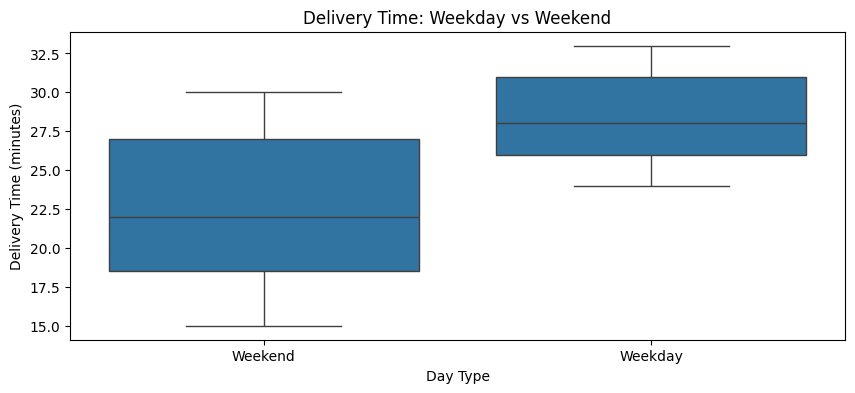

In [25]:
# Select the number columns we want to compare
numeric_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time',
                'total_fulfillment_time', 'platform_commission']

# Calculate correlation between each pair of columns
# 1.0 = perfect relationship, 0 = no relationship, -1 = opposite relationship
corr = df[numeric_cols].corr()

# Heatmap: colour-coded grid showing how strongly each pair of columns is related
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap: How Related Are the Key Columns?')
plt.tight_layout()
plt.show()

# Box plot: compare the spread of delivery times on weekdays vs weekends
# The box shows the middle 50% of values; the line inside is the median
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')
plt.title('Delivery Time: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Delivery Time (minutes)')
plt.show()

**Reading the results:**
- **Heatmap:** Commission and order cost are almost perfectly correlated (0.97), which makes sense since commission is calculated directly from cost. Importantly, **food prep time and delivery time are NOT correlated with each other.** They are separate problems that need separate fixes.
- **Box plot:** Weekday delivery times are noticeably higher than weekend ones. The box shows where the middle 50% of values sit; the line inside is the median (middle value).

### Which restaurants show strong customer ratings at scale?

In [26]:
# 1) Keep only rows where a rating exists
rated_orders = df.dropna(subset=['rating_num'])

# 2) For each restaurant, calculate how many ratings it has and the average rating
restaurant_stats = rated_orders.groupby('restaurant_name')['rating_num'].agg(['count', 'mean']).reset_index()

# 3) Keep restaurants with more than 50 ratings
high_volume_restaurants = restaurant_stats[restaurant_stats['count'] > 50]

# 4) From those, keep restaurants with average rating above 4.0
promo = high_volume_restaurants[high_volume_restaurants['mean'] > 4.0]

# 5) Sort best to worst by average rating
promo = promo.sort_values('mean', ascending=False)

promo

,restaurant_name,count,mean
132,The Meatball Shop,84,4.511905
16,Blue Ribbon Fried Chicken,64,4.328125
117,Shake Shack,133,4.278195
17,Blue Ribbon Sushi,73,4.219178


**Result:** **4 restaurants** pass both tests more than 50 rated orders AND an average above 4.0. These are The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack, and Blue Ribbon Sushi. They have proven track records with real volume, making them strong candidates for a promotion or feature placement.

### What is the total platform commission revenue?

In [27]:
# Add up all the commission values across every order to get total revenue
net_revenue = df['platform_commission'].sum()
print(f'Total platform commission revenue: ${net_revenue:,.2f}')

Total platform commission revenue: $6,166.50


**Result:** MunchLink earned a total of **$6,166.50** in commission from these 1,898 orders. This is based on charging 25% on orders above $20 and 15% on orders between $5 and $20.

### What share of orders exceed the 60-minute fulfillment threshold?

In [28]:
# Keep orders that took more than 60 minutes in total
slow_orders = df[df['total_fulfillment_time'] > 60]

# Count totals
total_orders = len(df)
slow_order_count = len(slow_orders)

# Convert to percentage
pct_over_60 = (slow_order_count / total_orders) * 100

print(f'Orders over 60 minutes: {slow_order_count} out of {total_orders}')
print(f'Orders exceeding 60 minutes (prep + delivery): {pct_over_60:.2f}%')

Orders over 60 minutes: 200 out of 1898
Orders exceeding 60 minutes (prep + delivery): 10.54%


**Result:** **10.54% of orders** (roughly 1 in every 10) took more than 60 minutes from order to delivery. For a food delivery platform, this is a key pain point. Customers waiting over an hour are more likely to complain or leave a bad rating.

### How does average delivery time differ between weekdays and weekends?

In [29]:
# Group orders by Weekday vs Weekend and calculate the average delivery time for each group
delivery_by_day = df.groupby('day_of_the_week')['delivery_time'].mean().round(2)
print(delivery_by_day)

day_of_the_week
Weekday    28.34
Weekend    22.47
Name: delivery_time, dtype: float64


**Result:** Weekend deliveries average about **22 minutes**. Weekday deliveries average about **28 minutes**, roughly 6 minutes slower. Weekday roads tend to be busier (traffic, lunch rushes, office areas), which slows drivers down.

### How do customer ratings vary across fulfillment speed buckets?

In [30]:
# Keep only rows where we have a rating
rated_orders = df.dropna(subset=['rating_num'])

# Find average rating for each speed group
rating_by_speed = rated_orders.groupby('speed_bucket')['rating_num'].mean()

# Round to 2 decimal places for clean display
rating_by_speed = rating_by_speed.round(2)

print(rating_by_speed)

speed_bucket
Fast      4.43
Normal    4.33
Slow      4.36
Name: rating_num, dtype: float64


**Result:** Fast deliveries get an average rating of **4.43**, Slow gets 4.36, and Normal gets 4.33. Speed does slightly improve ratings, but the difference is small meaning food quality and restaurant experience likely matter more to customers than just getting the food quickly.

### Which delivery zones have the highest service issue rates?

In [31]:
# Count total orders in each zone
zone_totals = df.groupby('delivery_zone').size()

# Count only service-issue orders (handles either Yes/No or 1/0 encoding)
issue_mask = df['service_issue_flag'].isin(['Yes', 1, True])
zone_issues = df[issue_mask].groupby('delivery_zone').size()

# Service issue rate = (issue count / total count) * 100
issue_rate_by_zone = (zone_issues / zone_totals) * 100

# If a zone has no issues, fill missing with 0
issue_rate_by_zone = issue_rate_by_zone.fillna(0)

# Make output neat and sorted
issue_rate_by_zone = issue_rate_by_zone.round(2).sort_values(ascending=False)

print(issue_rate_by_zone)

delivery_zone
Uptown      13.22
Midtown     10.49
Downtown    10.38
Suburban     8.01
dtype: float64


**Result:** **Uptown has the worst service issue rate (~13%)**, roughly 1 in every 8 orders there has a problem. Suburban performs best (~8%). Uptown likely needs more delivery drivers, better routing, or closer restaurant partnerships to improve its issue rate.

### Which cuisine categories generate the most platform commission?

cuisine_type
American          1878.35
Japanese          1478.26
Italian            966.97
Chinese            690.04
Mexican            256.73
Indian             247.00
Middle Eastern     193.52
Mediterranean      136.32
Thai                78.05
French              76.19
Southern            68.78
Spanish             47.23
Korean              33.31
Vietnamese          15.75
Name: platform_commission, dtype: float64


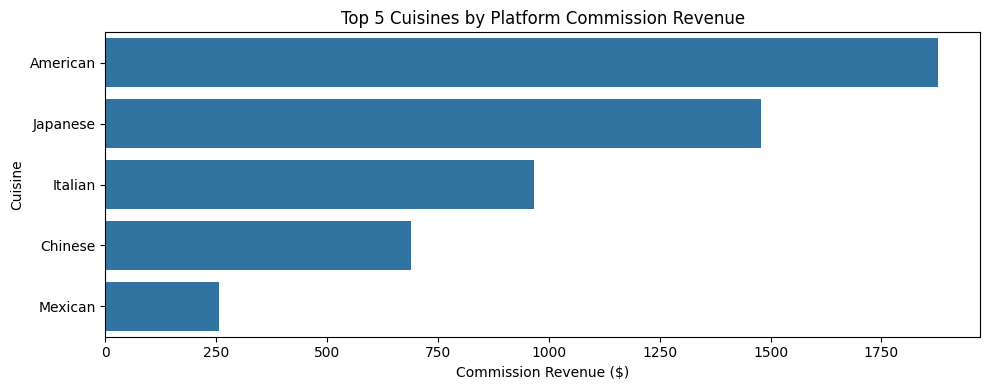

In [32]:
# Add up commission earned by each cuisine
commission_by_cuisine = df.groupby('cuisine_type')['platform_commission'].sum()

# Round and sort from highest to lowest
commission_by_cuisine = commission_by_cuisine.round(2)
commission_by_cuisine = commission_by_cuisine.sort_values(ascending=False)

print(commission_by_cuisine)

# Show the top 5 earners as a bar chart
top_commission = commission_by_cuisine.head(5)

plt.figure(figsize=(10, 4))
sns.barplot(x=top_commission.values, y=top_commission.index)
plt.title('Top 5 Cuisines by Platform Commission Revenue')
plt.xlabel('Commission Revenue ($)')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

**Result:** **American cuisine generates the most commission ($1,878)**, driven by its high order volume. **Japanese is second ($1,478)**, partly because Japanese orders tend to be more expensive. Italian is third ($967). Cuisines like Korean, Spanish, and Vietnamese generate very little, as they are niche offerings on the platform.

## Summary & Business Recommendations

## Summary

### Key Findings

- 736 orders (38.8%) have no rating
- 10.54% of orders exceed 60-minute fulfillment time
- Shake Shack leads with 219 orders
- American cuisine dominates with 415 orders on weekends
- Average delivery time: 24.16 minutes
- Total platform commission: $6,166.50
- Weekday deliveries take longer (28.34 min) than weekend (22.47 min)
- Uptown zone has highest service issue rate (13.22%)